In [ ]:
# Colab setup: mount Drive, set project root, add src to path
import sys, os

# Install deps if running on Colab
if 'google.colab' in sys.modules:
    try:
        import torch, torchvision, cv2  # noqa: F401
    except Exception:
        %pip -q install torch torchvision opencv-python tqdm
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/AML-ETH-Project2'
else:
    # Fallback for local runs (adjust if needed)
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC_PATH = os.path.join(PROJECT_ROOT, 'src')
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print('Project root:', PROJECT_ROOT)
print('Using src path:', SRC_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/AML-ETH-Project2
Using src path: /content/drive/MyDrive/AML-ETH-Project2/src


In [ ]:
# Clear cached modules to force reimport of updated code
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['dataset_bbox', 'train_bbox', 'BBoxRegressor', 'utils']):
        del sys.modules[mod]

print("✓ Module cache cleared - fresh import will happen next")

✓ Module cache cleared - fresh import will happen next


In [ ]:
from models.BBoxRegressor import BBoxRegressor
from dataset_bbox import BBoxDataset
from train_bbox import train_bbox_regressor
from utils.utilities import load_zipped_pickle, make_train_test_split
from torch.utils.data import DataLoader
import torch
import os

# Load data (via mounted Drive path)
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'raw', 'train.pkl')
data = load_zipped_pickle(DATA_PATH)
train_data, val_data = make_train_test_split(data, test_ratio=0.2)

# Create datasets
train_dataset = BBoxDataset(train_data)
val_dataset = BBoxDataset(val_data)

# Create dataloaders (Colab-friendly workers)
pin_mem = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=pin_mem)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=pin_mem)

# Create model
model = BBoxRegressor(backbone='resnet18', pretrained=True)

# Train
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
save_dir = PROJECT_ROOT + '/weights'
train_bbox_regressor(model, train_loader, val_loader, save_dir, epochs=20, device=device)

Using device: cuda


Epoch 1/20 [VAL]: 100%|██████████| 18/18 [00:02<00:00,  7.67it/s]


Epoch 1: Train Loss=0.0020, Val Loss=0.0099
✓ Best model saved (Val Loss=0.0099)


Epoch 2/20 [VAL]: 100%|██████████| 18/18 [00:01<00:00,  9.75it/s]


Epoch 2: Train Loss=0.0013, Val Loss=0.0071
✓ Best model saved (Val Loss=0.0071)


...

Epoch 10: Train Loss=0.0006, Val Loss=0.0049


Epoch 11/20 [VAL]: 100%|██████████| 18/18 [00:02<00:00,  7.54it/s]


Epoch 11: Train Loss=0.0006, Val Loss=0.0083


Epoch 12/20 [TRAIN]:  52%|█████▏    | 311/599 [00:19<00:17, 16.30it/s]


KeyboardInterrupt: 

✓ Model loaded from /content/drive/MyDrive/AML-ETH-Project2/weights/bbox_regressor_best.pth

Validation set predictions:


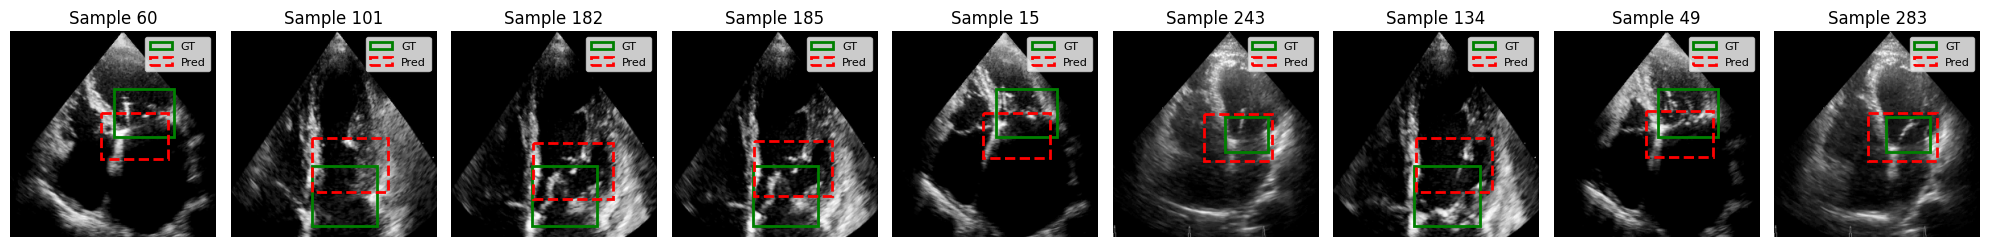

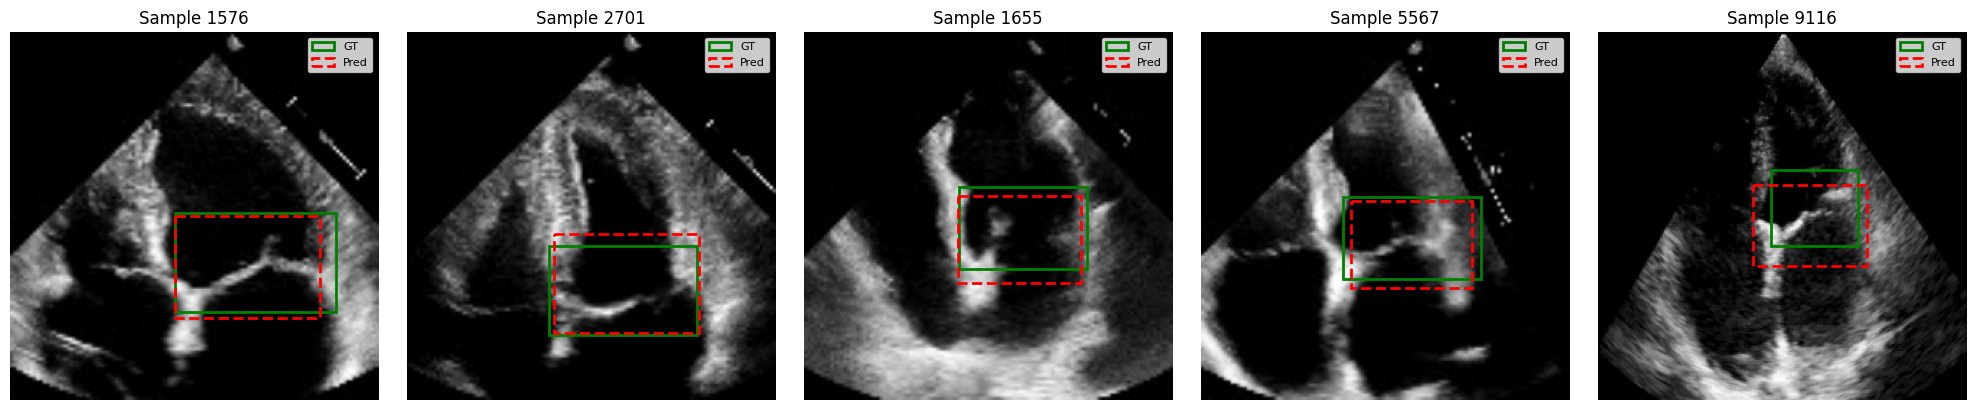

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load trained model
weights_path = os.path.join(PROJECT_ROOT, 'weights', 'bbox_regressor_best.pth')
model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()
print(f"✓ Model loaded from {weights_path}")

# Inference function
def predict_bbox(image_tensor, model, device):
    """
    Predict normalized bbox from image.
    image_tensor: (1, 3, H, W) or (3, H, W)
    Returns: normalized bbox [x_min, y_min, x_max, y_max] in [0, 1]
    """
    if image_tensor.ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)
    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        bbox = model(image_tensor)
    return bbox.cpu().numpy()[0]  # (4,)

# Visualize predictions vs labels
def visualize_bbox_predictions(dataset, indices=None, num_samples=5, figsize=(15, 3)):
    """
    Visualize predicted vs ground truth bboxes for validation samples.
    """
    if indices is None:
        indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    fig, axes = plt.subplots(1, len(indices), figsize=figsize)
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        sample = dataset[idx]
        image = sample['image']  # (3, H, W)
        bbox_label = sample['bbox'].numpy()  # (4,) normalized

        # Predict
        bbox_pred = predict_bbox(image, model, device)  # (4,) normalized

        # Convert image to display format
        img_display = image.numpy()
        # Assume image is replicated grayscale (3, H, W) -> take first channel
        img_display = img_display[0]  # (H, W)

        # Plot
        ax.imshow(img_display, cmap='gray')
        H, W = img_display.shape

        # Draw ground truth bbox (green)
        x_min_gt, y_min_gt, x_max_gt, y_max_gt = bbox_label
        rect_gt = patches.Rectangle(
            (x_min_gt * W, y_min_gt * H),
            (x_max_gt - x_min_gt) * W,
            (y_max_gt - y_min_gt) * H,
            linewidth=2, edgecolor='green', facecolor='none', label='GT'
        )
        ax.add_patch(rect_gt)

        # Draw predicted bbox (red)
        x_min_pred, y_min_pred, x_max_pred, y_max_pred = bbox_pred
        rect_pred = patches.Rectangle(
            (x_min_pred * W, y_min_pred * H),
            (x_max_pred - x_min_pred) * W,
            (y_max_pred - y_min_pred) * H,
            linewidth=2, edgecolor='red', facecolor='none', label='Pred', linestyle='--'
        )
        ax.add_patch(rect_pred)

        ax.set_title(f"Sample {idx}")
        ax.legend(loc='upper right', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize a few validation samples
print("\nValidation set predictions:")
visualize_bbox_predictions(val_dataset, num_samples=9, figsize=(20, 4))
visualize_bbox_predictions(train_dataset, num_samples=5, figsize=(20, 4))